# Chapter 3 — Policy-based RL
*Reinforcement Learning: An Overview*, Murphy (arXiv:2412.05265v5) — §3

Policy gradient theorem · REINFORCE · Actor-Critic · PPO · off-policy methods

In [1]:
%pip install -q numpy matplotlib torch gymnasium
print('ready')

/Users/ppcc/Desktop/Reinforcement-Learning/.venv/bin/python3: No module named pip


Note: you may need to restart the kernel to use updated packages.
ready


## 3.1 Policy Gradient Theorem

Parameterise $\pi_\theta(a\mid s)$. Objective:
$$J(\theta)=\mathbb{E}_\tau[R(\tau)]$$

$$\nabla_\theta J(\theta)=\mathbb{E}_\tau\Bigl[\sum_t\nabla_\theta\log\pi_\theta(a_t\mid s_t)\cdot G_t\Bigr]$$

Subtracting baseline $b(s_t)$ reduces variance without adding bias.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch, torch.nn as nn, torch.optim as optim

try:
    import gymnasium as gym
    gym.make("CartPole-v1").close()
    USE_CP = True
    print("CartPole-v1 available")
except Exception as e:
    USE_CP = False
    print(f"CartPole unavailable: {e}")


CartPole-v1 available


Training REINFORCE on CartPole-v1 (~30s)…


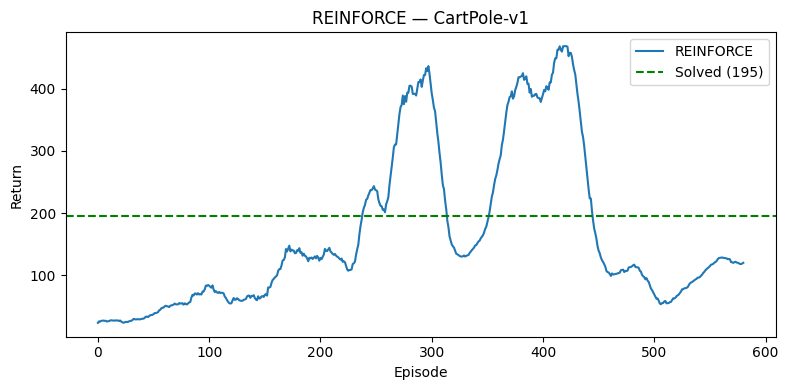

Final 50ep mean: 119.7


In [3]:
class PolicyNet(nn.Module):
    def __init__(self, obs_dim, n_act, h=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, h), nn.ReLU(),
            nn.Linear(h, h), nn.ReLU(),
            nn.Linear(h, n_act),
        )
    def forward(self, x): return torch.softmax(self.net(x), dim=-1)


def reinforce(n_ep=600, gamma=0.99, lr=1e-3):
    import gymnasium as gym
    env = gym.make("CartPole-v1")
    pol = PolicyNet(env.observation_space.shape[0], env.action_space.n)
    opt = optim.Adam(pol.parameters(), lr=lr)
    ep_rets = []

    for _ in range(n_ep):
        obs, _ = env.reset()
        lps, rews = [], []
        for _ in range(500):
            x = torch.tensor(obs, dtype=torch.float32)
            d = torch.distributions.Categorical(pol(x))
            a = d.sample()
            lps.append(d.log_prob(a))
            obs, r, term, trunc, _ = env.step(a.item())
            rews.append(r)
            if term or trunc: break

        G, rets = 0.0, []
        for r in reversed(rews): G = r + gamma*G; rets.insert(0, G)
        rets = torch.tensor(rets, dtype=torch.float32)
        rets = (rets - rets.mean()) / (rets.std() + 1e-8)

        loss = -torch.stack([lp*G for lp,G in zip(lps, rets)]).sum()
        opt.zero_grad(); loss.backward(); opt.step()
        ep_rets.append(sum(rews))

    env.close()
    return pol, ep_rets


if USE_CP:
    print("Training REINFORCE on CartPole-v1 (~30s)…")
    pol_rf, ret_rf = reinforce()
    smooth = lambda x, w=20: np.convolve(x, np.ones(w)/w, mode="valid")
    plt.figure(figsize=(8,4))
    plt.plot(smooth(ret_rf), label="REINFORCE")
    plt.axhline(195, color="g", ls="--", label="Solved (195)")
    plt.xlabel("Episode"); plt.ylabel("Return")
    plt.title("REINFORCE — CartPole-v1"); plt.legend(); plt.tight_layout(); plt.show()
    print(f"Final 50ep mean: {np.mean(ret_rf[-50:]):.1f}")


## 3.2 Actor-Critic

Replace $G_t$ with TD advantage $\delta_t=r_t+\gamma V_\phi(s_{t+1})-V_\phi(s_t)$.

- **Actor** $\pi_\theta$: $\nabla_\theta J\approx\delta_t\nabla_\theta\log\pi_\theta(a_t\mid s_t)$
- **Critic** $V_\phi$: minimises $\delta_t^2$

Training Actor-Critic on CartPole-v1…


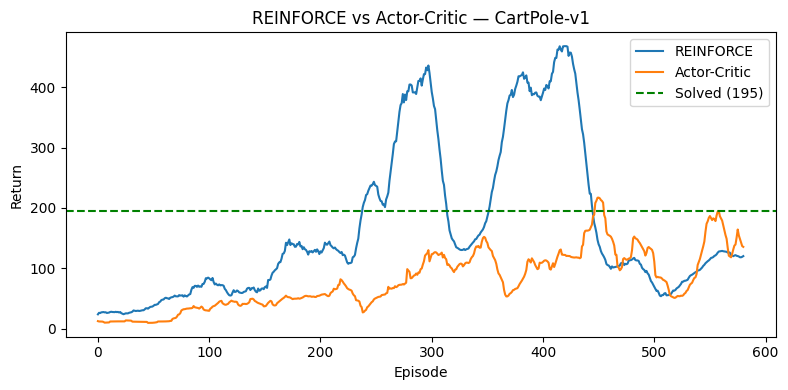

In [4]:
class ACNet(nn.Module):
    def __init__(self, obs_dim, n_act, h=64):
        super().__init__()
        self.shared = nn.Sequential(nn.Linear(obs_dim,h), nn.ReLU())
        self.actor  = nn.Linear(h, n_act)
        self.critic = nn.Linear(h, 1)
    def forward(self, x):
        h = self.shared(x)
        return torch.softmax(self.actor(h), dim=-1), self.critic(h).squeeze(-1)


def actor_critic(n_ep=600, gamma=0.99, lr=3e-3):
    import gymnasium as gym
    env = gym.make("CartPole-v1")
    model = ACNet(env.observation_space.shape[0], env.action_space.n)
    opt = optim.Adam(model.parameters(), lr=lr)
    ep_rets = []

    for _ in range(n_ep):
        obs, _ = env.reset(); ep_r = 0
        for _ in range(500):
            x = torch.tensor(obs, dtype=torch.float32)
            probs, V = model(x)
            d = torch.distributions.Categorical(probs); a = d.sample()
            obs2, r, term, trunc, _ = env.step(a.item())
            done = term or trunc
            with torch.no_grad():
                _, V2 = model(torch.tensor(obs2, dtype=torch.float32))
            td = r + gamma*V2*(1-float(done)) - V
            loss = -d.log_prob(a)*td.detach() + 0.5*td.pow(2)
            opt.zero_grad(); loss.backward(); opt.step()
            obs = obs2; ep_r += r
            if done: break
        ep_rets.append(ep_r)

    env.close()
    return model, ep_rets


if USE_CP:
    print("Training Actor-Critic on CartPole-v1…")
    _, ret_ac = actor_critic()
    plt.figure(figsize=(8,4))
    plt.plot(smooth(ret_rf), label="REINFORCE")
    plt.plot(smooth(ret_ac), label="Actor-Critic")
    plt.axhline(195, color="g", ls="--", label="Solved (195)")
    plt.xlabel("Episode"); plt.ylabel("Return")
    plt.title("REINFORCE vs Actor-Critic — CartPole-v1")
    plt.legend(); plt.tight_layout(); plt.show()


## 3.3 Proximal Policy Optimization (PPO)

Clip ratio to prevent destructive updates:
$$L^{\text{CLIP}}(\theta)=\mathbb{E}_t\Bigl[\min\bigl(r_t\hat{A}_t,\;\mathrm{clip}(r_t,1\pm\epsilon)\hat{A}_t\bigr)\Bigr]$$
where $r_t=\pi_\theta(a_t\mid s_t)/\pi_{\text{old}}(a_t\mid s_t)$.

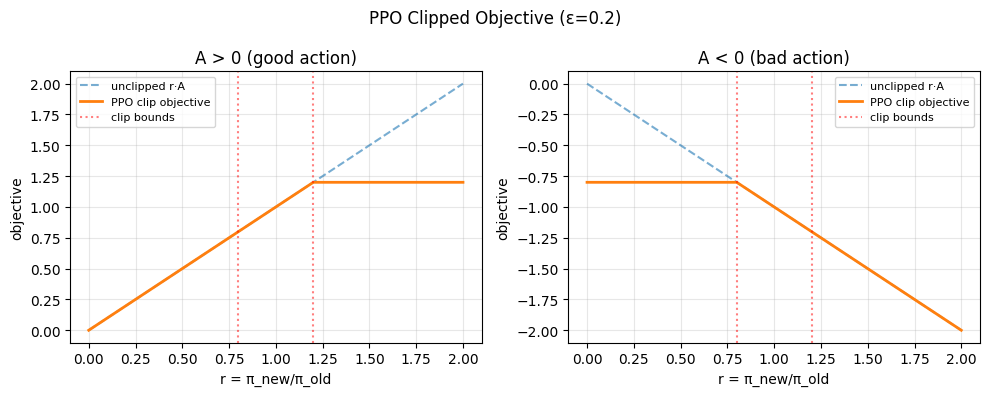

In [5]:
import numpy as np, matplotlib.pyplot as plt
eps = 0.2; ratios = np.linspace(0, 2, 300)

fig, axes = plt.subplots(1, 2, figsize=(10,4))
for ax, A_val, ttl in zip(axes, [1.0,-1.0], ["A > 0 (good action)","A < 0 (bad action)"]):
    unclip = ratios * A_val
    clip   = np.clip(ratios, 1-eps, 1+eps) * A_val
    L      = np.minimum(unclip, clip)
    ax.plot(ratios, unclip, "--", alpha=0.6, label="unclipped r·A")
    ax.plot(ratios, L, lw=2, label="PPO clip objective")
    ax.axvline(1-eps, color="red", ls=":", alpha=0.5)
    ax.axvline(1+eps, color="red", ls=":", alpha=0.5, label="clip bounds")
    ax.set_xlabel("r = π_new/π_old"); ax.set_ylabel("objective")
    ax.set_title(ttl); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
plt.suptitle("PPO Clipped Objective (ε=0.2)"); plt.tight_layout(); plt.show()
